## Import Library

In [1]:
import pandas as pd
import sys
sys.path.append('..')
from src.load_data import load_data
from src.technical_indicators import technical_analysis
from src.financial_metrics import financial_metrics
from src.plot import moving_averages
from src.plot import rsi_plot
from src.plot import cumulative
from src.plot import daily_returns
from src.plot import macd_result
from src.plot import correlation_map
%matplotlib inline

## Load and prepare the data

In [2]:
data = load_data('../data/META.csv')
data['Date'] = pd.to_datetime(data['Date'])
data.set_index('Date', inplace=True)
data.head(10)

,Close,High,Low,Open,Volume
Date,,,,,
2012-05-18,37.995762,44.724282,37.767172,41.792356,573576400
2012-05-21,33.821495,36.435382,32.797807,36.306177,168192700
2012-05-22,30.810066,33.384198,30.750434,32.410203,101786600
2012-05-23,31.803938,32.300874,31.167860,31.177799,73600000
2012-05-24,32.827625,33.006523,31.575347,32.748117,50237200
2012-05-25,31.714489,32.748118,30.919391,32.698425,37149800
2012-05-29,28.663300,31.495838,28.474463,31.287124,78063400
2012-05-30,28.017281,29.368947,27.689303,28.524156,57267900
2012-05-31,29.418642,29.488213,26.665613,28.375074,111639200


## Checking if there is NULL Value in the Data

In [3]:
data.info()

<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 2923 entries, 2012-05-18 to 2023-12-29
Data columns (total 5 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   Close   2923 non-null   float64
 1   High    2923 non-null   float64
 2   Low     2923 non-null   float64
 3   Open    2923 non-null   float64
 4   Volume  2923 non-null   int64  
dtypes: float64(4), int64(1)
memory usage: 137.0 KB


## Apply Analysis Indicators with TA-Lib

In [4]:
sma_20,ema_20,rsi,macd,macd_signal,macd_hist = technical_analysis(data['Close'])
ta_df = pd.DataFrame({"SMA_20": sma_20.index, "EMA_20":ema_20.index, "RSI":rsi.index, "MACD": macd.index, "MACD_Signal":macd_signal.index, "MACD_Hist": macd_hist.index})
ta_df.head(10)

,SMA_20,EMA_20,RSI,MACD,MACD_Signal,MACD_Hist
0,2012-05-18,2012-05-18,2012-05-18,2012-05-18,2012-05-18,2012-05-18
1,2012-05-21,2012-05-21,2012-05-21,2012-05-21,2012-05-21,2012-05-21
2,2012-05-22,2012-05-22,2012-05-22,2012-05-22,2012-05-22,2012-05-22
3,2012-05-23,2012-05-23,2012-05-23,2012-05-23,2012-05-23,2012-05-23
4,2012-05-24,2012-05-24,2012-05-24,2012-05-24,2012-05-24,2012-05-24
5,2012-05-25,2012-05-25,2012-05-25,2012-05-25,2012-05-25,2012-05-25
6,2012-05-29,2012-05-29,2012-05-29,2012-05-29,2012-05-29,2012-05-29
7,2012-05-30,2012-05-30,2012-05-30,2012-05-30,2012-05-30,2012-05-30
8,2012-05-31,2012-05-31,2012-05-31,2012-05-31,2012-05-31,2012-05-31
9,2012-06-01,2012-06-01,2012-06-01,2012-06-01,2012-06-01,2012-06-01


## Financial Metrics

In [5]:
returns,cumulative_returns, volatility = financial_metrics(data['Close'])
volatility_percent = volatility* 100
print(f"Annualized Volatility(Measure of how risky) is: {volatility_percent:.2f}%")

Annualized Volatility(Measure of how risky) is: 40.13%


## Visualize Data

### Stock close price and moving averages

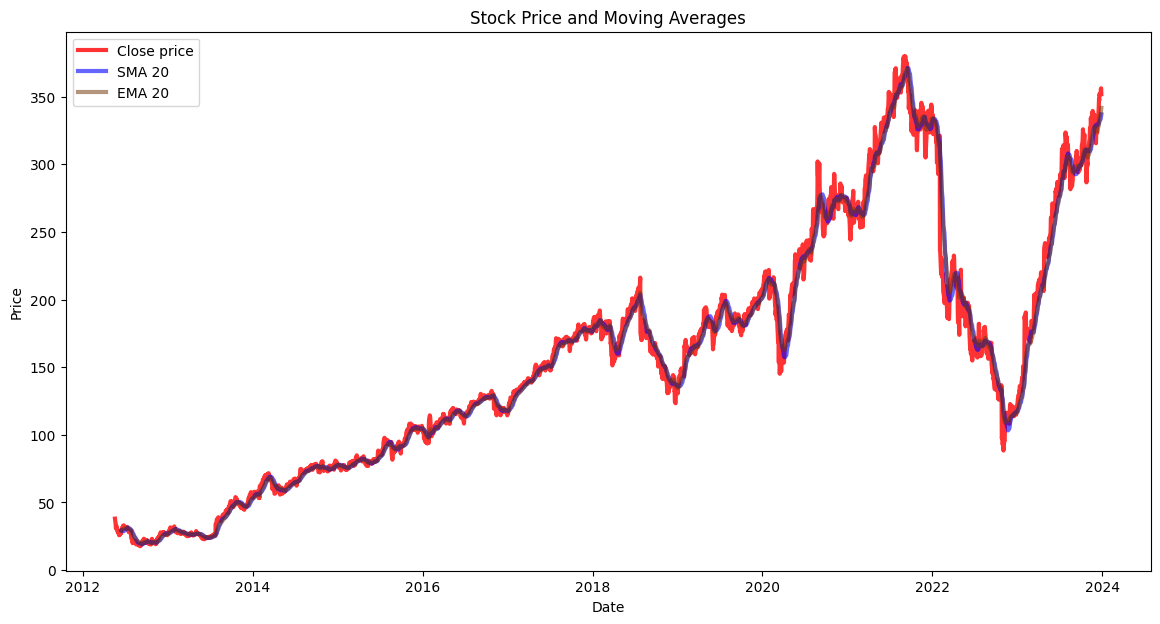

In [6]:
moving_averages(data['Close'], sma_20, ema_20)

## RSI Plot

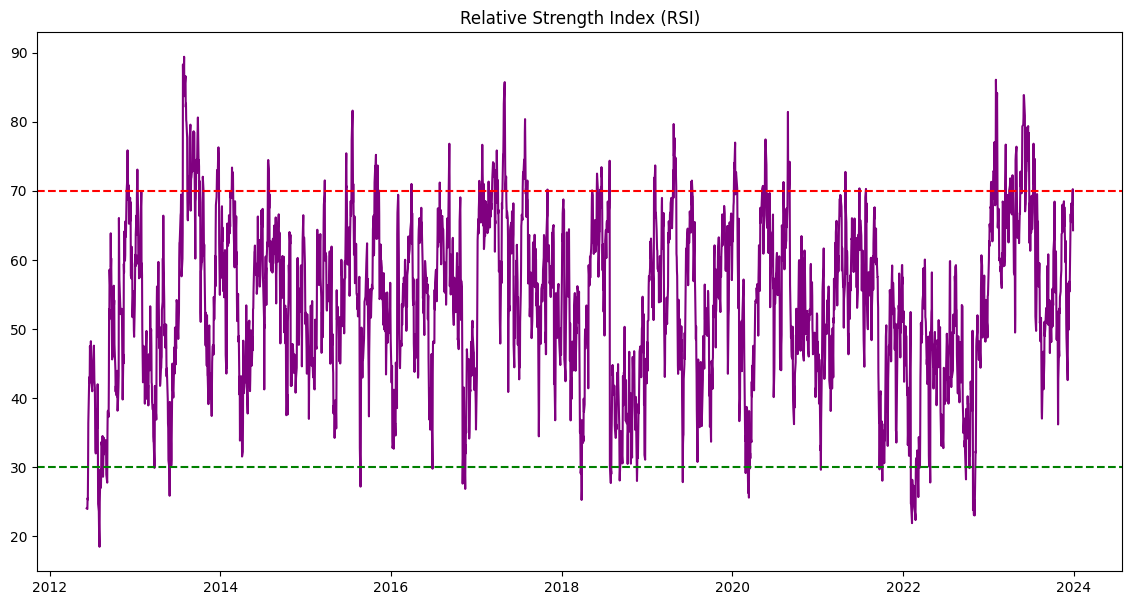

In [7]:
rsi_plot(rsi)

### Cumulative Returns

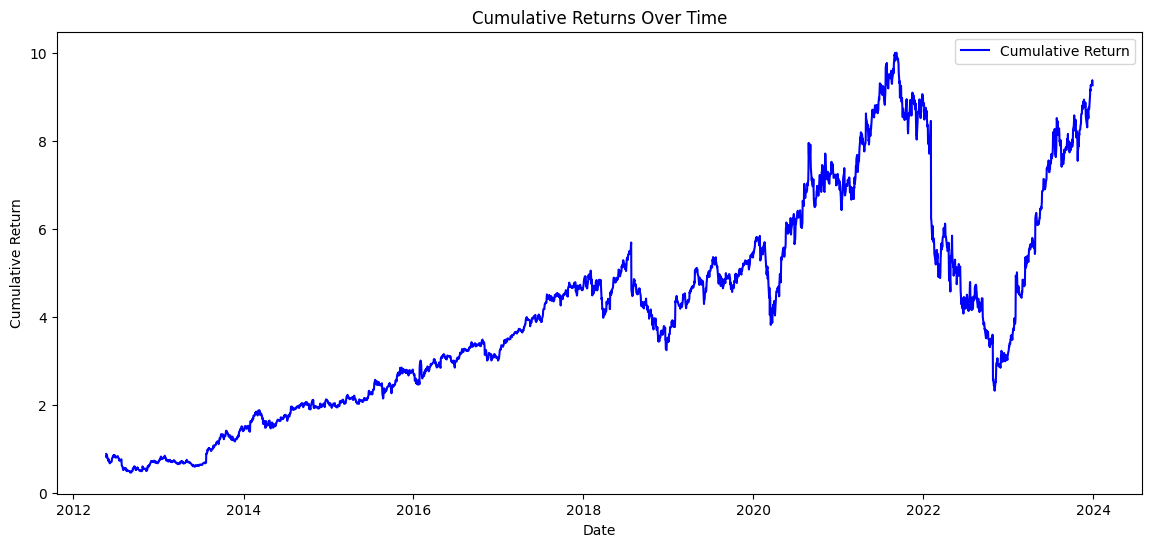

In [8]:
cumulative(cumulative_returns)

### Daily Returns

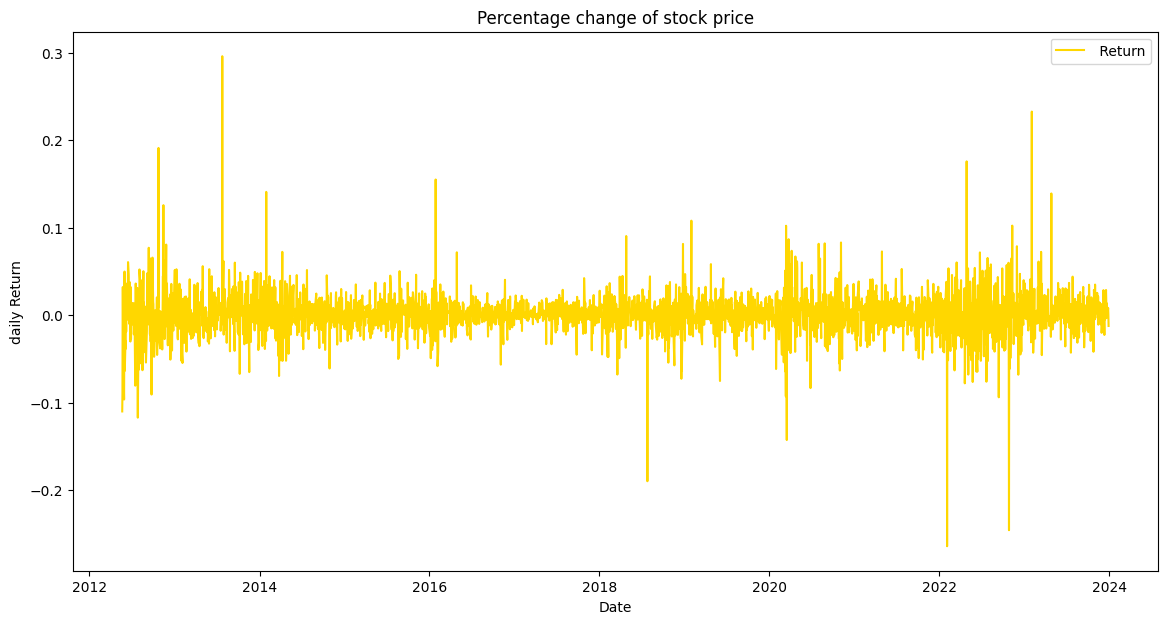

In [9]:
daily_returns(returns)

### Moving Average Convergence Divergence

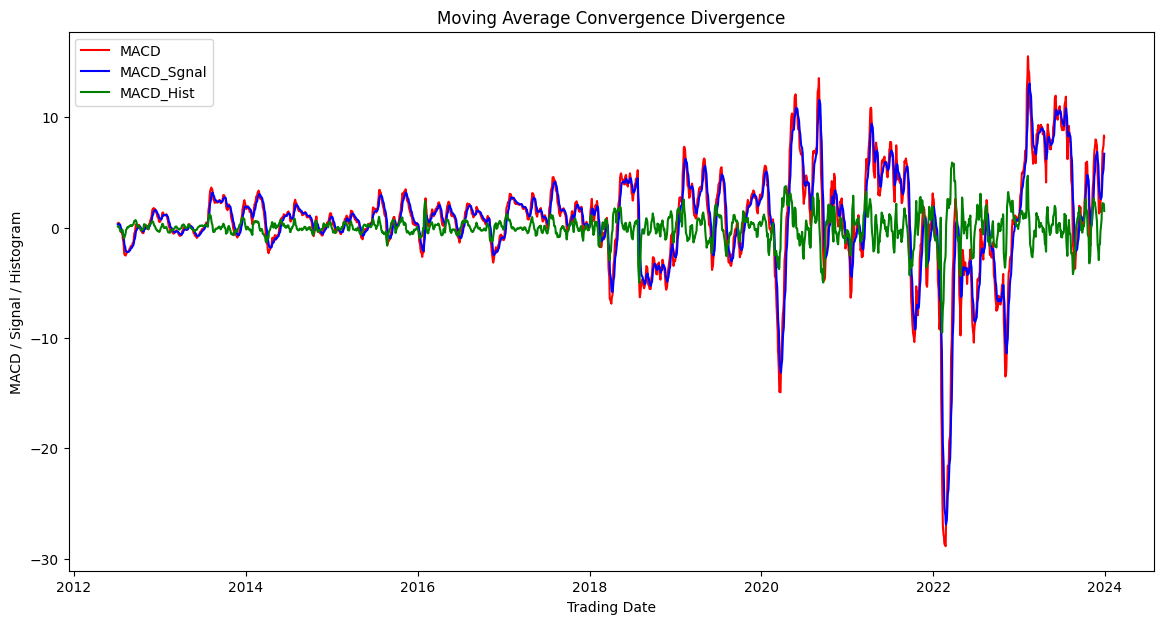

In [10]:
macd_result(macd,macd_signal, macd_hist) 

### Correlation of The Data's Columns

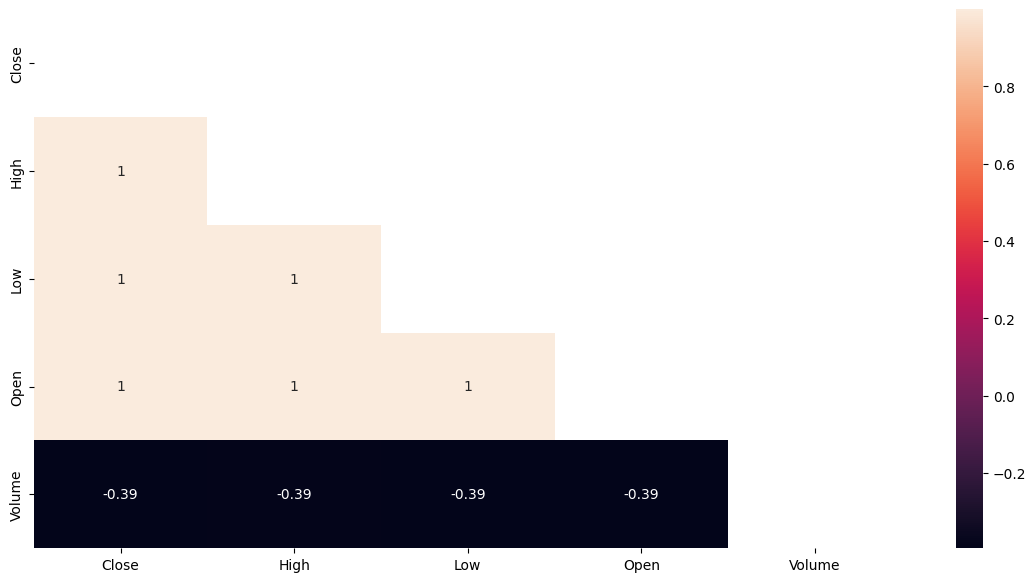

In [11]:
corr_data = data.corr()
correlation_map(corr_data)